In [1]:
# Configuration
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("..")

In [2]:
# Setup
from importlib import import_module
from typing import cast

import numpy as np
from keras import ops
from keras.models import Model, load_model

from src.utils import (
    show_learned_cut,
    show_learned_cuts,
    show_learned_importance,
    show_record_dataset,
    show_record_dataset_correlation,
)

In [3]:
# Parameters

# Dataset
dataset_name = "mock5"
n_samples = 200000
seed = 42

# Model
model_builder_name = "LearnableCutFlowSequential"
centers = [-2, 2, 0, 0, -1, -5, -1.8]
n_epochs = 200
batch_size = 512

# Figure
bins = np.linspace(-10, 10, 101)
feature_names = ["x1", "x2", "x3", "x4", "x5", "x7", "x9"]
feature_names_latex = ["$x_1$", "$x_2$", "$x_3$", "$x_4$", "$x_5$", "$x_7$", "$x_9$"]

x_train.shape=(100000, 7)
y_train.shape=(100000, 1)
x_test.shape=(100000, 7)
y_test.shape=(100000, 1)


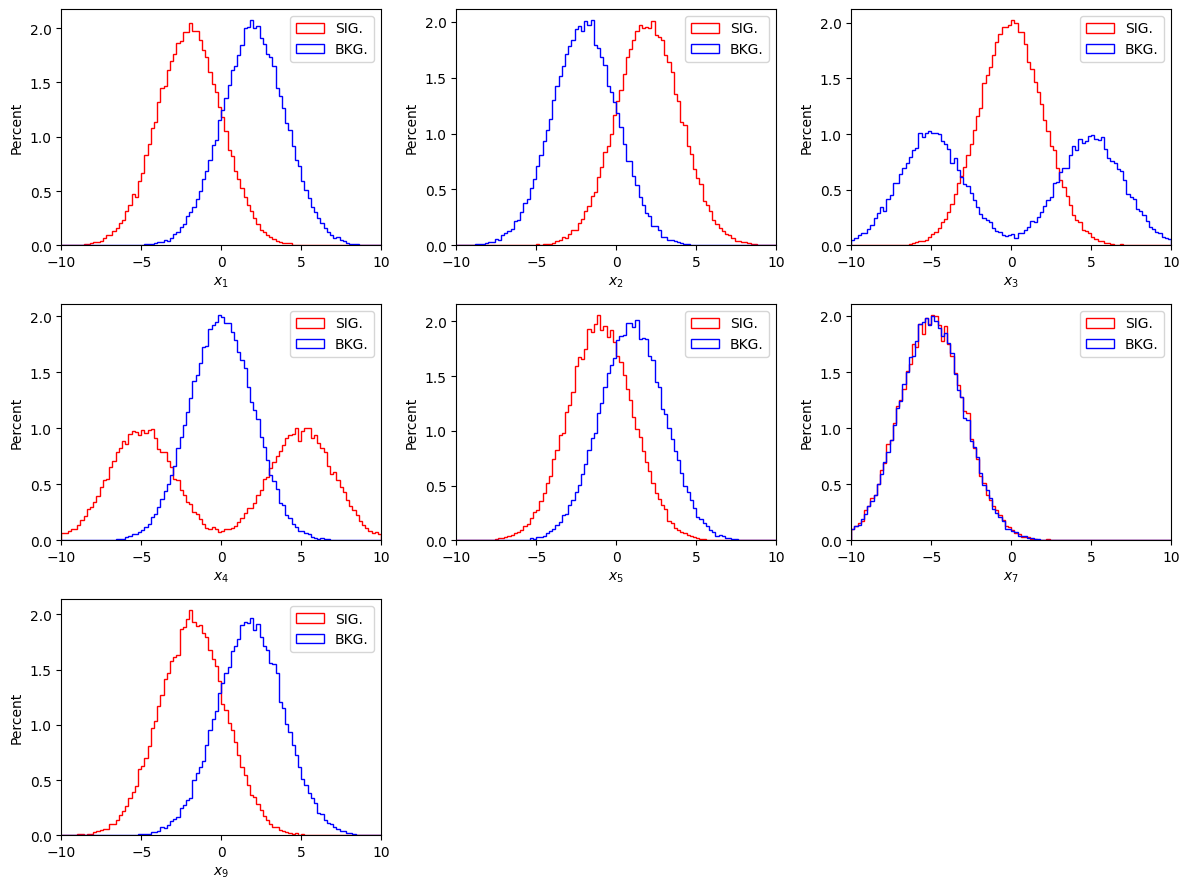

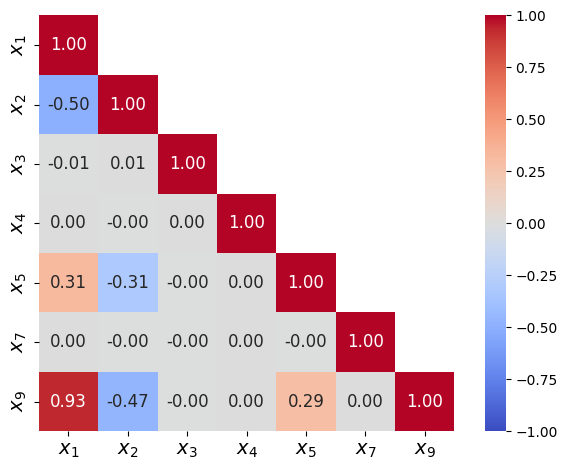

In [4]:
# Dataset
load_data = import_module(f"src.datasets.{dataset_name}").load_data
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

# Figure: feature distribution
show_record_dataset(x_train, y_train, bins, feature_names_latex)

# Figure: feature correlation
show_record_dataset_correlation(x_train, feature_names_latex)

In [5]:
# Model
ModelBuilder = getattr(import_module("src.models"), model_builder_name)
model = ModelBuilder(x_train.shape, centers, name="lcf_seq")
model.normalization.adapt(x_train)
model.compile(optimizer="adam", loss="crossentropy")
model.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0522
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0494
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0474
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0457
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0441
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0428
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0411
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0404
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0679
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0980
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1011
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1029
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1035
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1054
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 

In [6]:
# Save model
checkpoint_name = f"exp-{dataset_name}-{model.name}"
model.save(f"checkpoints/{checkpoint_name}.keras")
checkpoint = cast(Model, load_model(f"checkpoints/{checkpoint_name}.keras"))

In [7]:
# Analysis: metrics
y_pred = checkpoint.predict(x_test, batch_size=batch_size)
y_true = y_test

tp = ops.sum((y_true == 1) & (y_pred == 1))
fp = ops.sum((y_true == 0) & (y_pred == 1))
tn = ops.sum((y_true == 0) & (y_pred == 0))
fn = ops.sum((y_true == 1) & (y_pred == 0))

n_preds_true = ops.add(tp, tn)
n_preds_false = ops.add(fp, fn)
n_positives = ops.add(tp, fp)
n_samples = ops.add(n_preds_true, n_preds_false)

accuracy = ops.divide(n_preds_true, n_samples)
precision = ops.divide(tp, n_positives)
significance = ops.divide(tp, ops.sqrt(fp))

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
True positives.......39732
False positives.......1547
Accuracy............0.8833
Precision...........0.9625
Significance.....1010.1719


In [8]:
# Analysis: check metrics via learned cuts
mask = ops.ones_like(x_test[:, 0], dtype="bool")
n_features = x_test.shape[1]
selection = (
    checkpoint.learned_importance > 1 / n_features * checkpoint.importance_min_percent
)
for i, cut_report in enumerate(checkpoint.learned_cuts_report):
    if not selection[i]:
        continue

    x_i = x_test[:, i]
    boundaries = cut_report["boundaries"]
    index = cut_report["index"]

    if cut_report["case"] == "left":
        mask_i = x_i < boundaries[index]
    elif cut_report["case"] == "right":
        mask_i = x_i > boundaries[index]
    elif cut_report["case"] == "middle":
        mask_i = ops.logical_and(boundaries[0] < x_i, x_i < boundaries[1])
    else:
        mask_i = ops.logical_or(x_i < boundaries[0], boundaries[1] < x_i)
    mask = ops.logical_and(mask, mask_i)

y_pred_cut = ops.cast(mask, dtype="float32")
y_pred_cut = ops.reshape(y_pred_cut, y_test.shape)
tp = ops.sum((y_pred_cut == 1) & (y_test == 1))
fp = ops.sum((y_pred_cut == 1) & (y_test == 0))
tn = ops.sum((y_pred_cut == 0) & (y_test == 0))
fn = ops.sum((y_pred_cut == 0) & (y_test == 1))

n_preds_true = ops.add(tp, tn)
n_preds_false = ops.add(fp, fn)
n_positives = ops.add(tp, fp)
n_samples = ops.add(n_preds_true, n_preds_false)

accuracy = ops.divide(n_preds_true, n_samples)
precision = ops.divide(tp, n_positives)
significance = ops.divide(tp, ops.sqrt(fp))

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

True positives.......39732
False positives.......1547
Accuracy............0.8833
Precision...........0.9625
Significance.....1010.1719


In [9]:
# Analysis: learned cuts
for learned_cut in checkpoint.learned_cuts:
    print(learned_cut)

x1 < 0.0150
x2 > -1.6515
-5.0721 < x3 < 5.0246
x4 < -0.4257 or x4 > 0.2771
x5 < -125246.9297
x6 > -309860.9375
x7 < -18547.5254


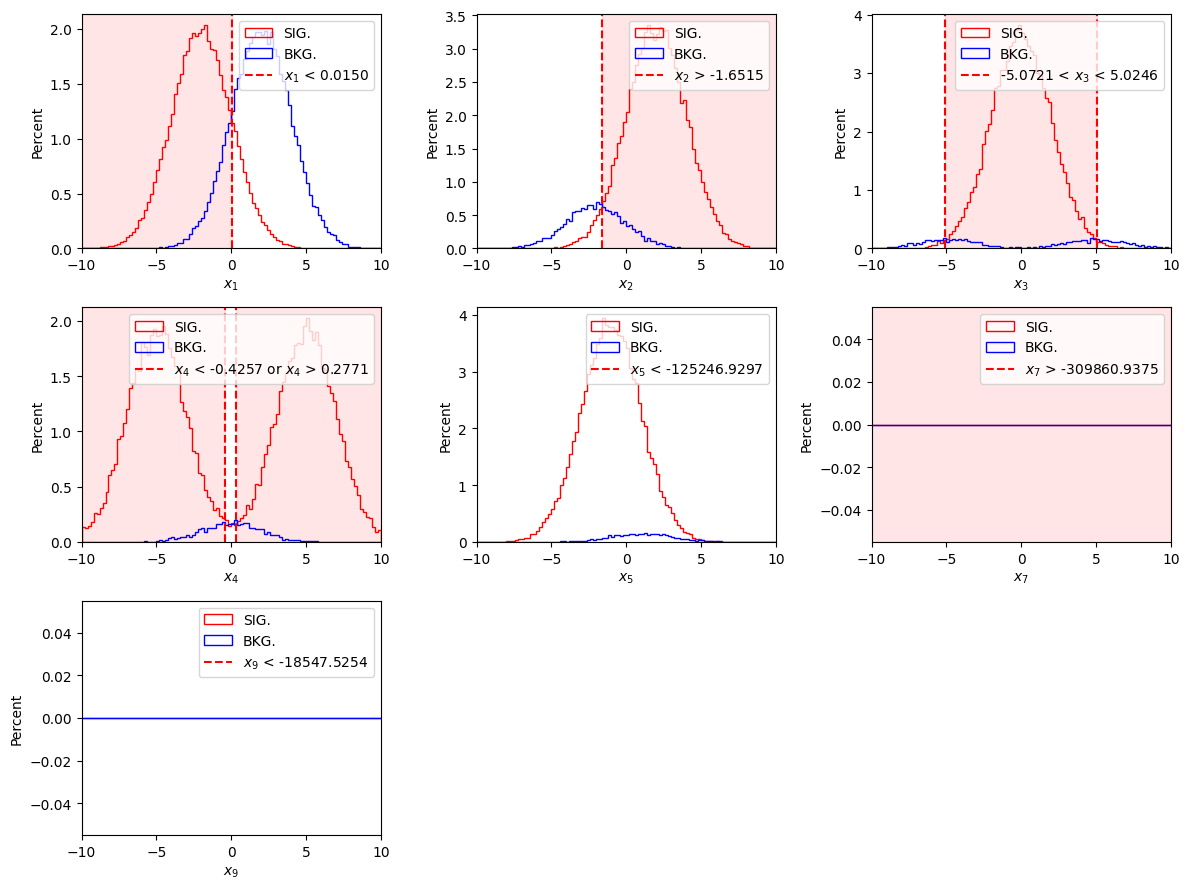

In [10]:
# Figure: learned cuts
show_learned_cuts(checkpoint, x_test, y_test, bins, feature_names_latex)

# Save in png and pdf
for i in range(len(checkpoint.learned_cuts)):
    show_learned_cut(
        i,
        checkpoint,
        x_test,
        y_test,
        bins,
        feature_names_latex[i],
        to_file=f"figures/exp-{dataset_name}-{checkpoint.name}-learned_cut_{i + 1}.png",
    )
for i in range(len(checkpoint.learned_cuts)):
    show_learned_cut(
        i,
        checkpoint,
        x_test,
        y_test,
        bins,
        feature_names_latex[i],
        to_file=f"figures/exp-{dataset_name}-{checkpoint.name}-learned_cut_{i + 1}.pdf",
    )

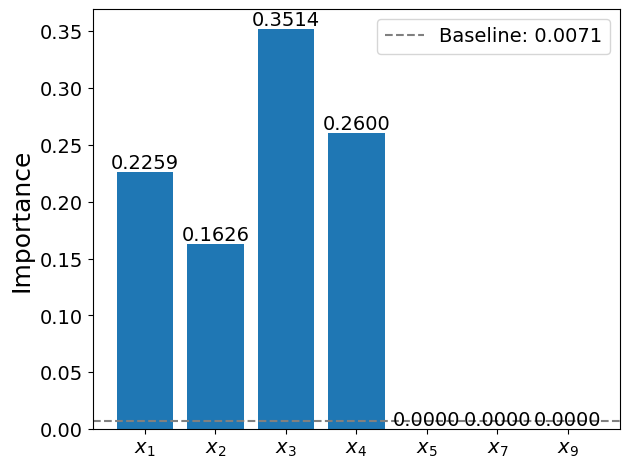

In [ ]:
# Figure: learned importance
show_learned_importance(checkpoint, feature_names_latex)

# Save in png and pdf
show_learned_importance(
    checkpoint,
    feature_names_latex,
    to_file=f"figures/exp-{dataset_name}-{checkpoint.name}-learned_importance.png",
)
show_learned_importance(
    checkpoint,
    feature_names_latex,
    to_file=f"figures/exp-{dataset_name}-{checkpoint.name}-learned_importance.pdf",
)